In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from matplotlib.colors import ListedColormap
from goatools.obo_parser import GODag

In [3]:
# Presets
models = [("Fusion", "fusion", 0.1), ("Structure", "struct", 0.4), ("ESM", "esm", 0.1), ("DeepFRIv1.0", "deepfri1", 0.29)]
protein = 'CopK'

# Load data
delta_data = pd.read_csv('fold_go_propagated_all_go_deltas.tsv', sep='\t')
# prot_data = delta_data[delta_data['Protein'] == protein]

# # Plotting data
# fold1 = prot_data['fold1'].iloc[0]
# fold2 = prot_data['fold2'].iloc[0]

# for model, model_prefix, threshold in models:
#     prot_data[f'{model_prefix}_fold1'] = prot_data[f'{model_prefix}_fold1'] >= threshold
#     prot_data[f'{model_prefix}_fold2'] = prot_data[f'{model_prefix}_fold2'] >= threshold

# Map GO IDs to GO class names
go_dag = GODag("go.obo")
go_map = {term.id: term.name for term in go_dag.values()}

delta_data['go_name'] = delta_data['go_id'].map(go_map)
delta_data.to_csv('fold_go_propagated_all_go_deltas.tsv', sep='\t', index=False)

go.obo: fmt(1.2) rel(2019-01-26) 47,381 Terms


In [ ]:
# Presets
models = [("Fusion", "fusion", 0.1), ("Structure", "struct", 0.4), ("ESM", "esm", 0.1), ("DeepFRIv1.0", "deepfri1", 0.29)]
protein = 'CopK'

# Load data
delta_data = pd.read_csv('fold_go_propagated_all_go_deltas.tsv', sep='\t')
prot_data = delta_data[delta_data['Protein'] == protein]

# Plotting data
fold1 = prot_data['fold1'].iloc[0]
fold2 = prot_data['fold2'].iloc[0]

for model, model_prefix, threshold in models:
    prot_data[f'{model_prefix}_fold1'] = prot_data[f'{model_prefix}_fold1'] >= threshold
    prot_data[f'{model_prefix}_fold2'] = prot_data[f'{model_prefix}_fold2'] >= threshold

# Map GO IDs to GO class names
go_dag = GODag("go.obo")
go_map = {term.id: term.name for term in go_dag.values()}

prot_data['go_name'] = prot_data['go_id'].map(go_map)

go.obo: fmt(1.2) rel(2019-01-26) 47,381 Terms


In [8]:
# --- X layout: same data columns as before; outer = model, inner = fold id (bottom ticks) ---
x_axis_grouping = {}
for model, model_prefix, _ in models:
    mf1, mf2 = f'{model_prefix}_fold1', f'{model_prefix}_fold2'
    x_axis_grouping[model] = [(mf1, fold1), (mf2, fold2)]

all_points = []
for model, _, _ in models:
    all_points.extend(x_axis_grouping[model])

cols_flat = [p[0] for p in all_points]
fold_tick_labels = [p[1] for p in all_points]  # inner labels → bottom (cf. tmp.py terms on bottom)

n_folds = 2
model_x_centers = [g * n_folds + n_folds / 2 for g in range(len(models))]  # 1, 3, 5 … heatmap column centers
category_boundaries = [(g + 1) * n_folds for g in range(len(models) - 1)]  # between model blocks

# Light column bands (same idea as tmp.py category_colors)
model_category_colors = {
    "Fusion": "#E6F5FF",
    "Structure": "#FFE6E6",
    "ESM": "#E6FFE6",
    "DeepFRIv1.0": "#F5E6FF"
}

cmap = ListedColormap(['#FFE6E6', '#E6FFE6'])
df_hm = prot_data.set_index('go_name')[cols_flat].astype(bool).astype(float)

to_move_term = 'zinc ion binding' # Move term to end to match hierarchy
new_order = [idx for idx in df_hm.index if idx != to_move_term] + [to_move_term]
df_hm = df_hm.reindex(new_order)

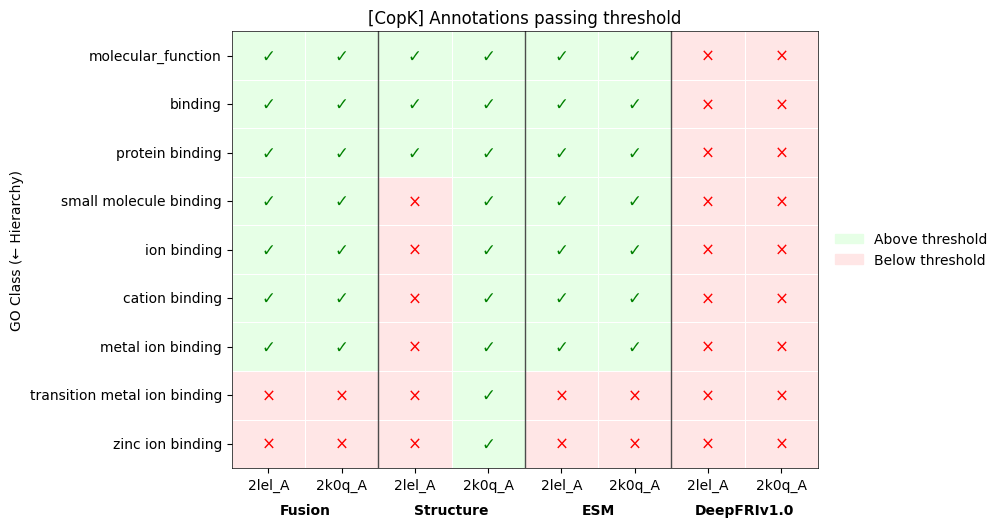

In [10]:
# --- Heatmap + tmp.py-style column bands + ✓/× markers ---
fig, ax = plt.subplots(figsize=(max(12, len(cols_flat) * 1.2), max(6, 0.22 * len(df_hm))))

sns.heatmap(
    df_hm,
    ax=ax,
    cmap=cmap,
    vmin=0,
    vmax=1,
    linewidths=0.5,
    linecolor='white',
    cbar=False,
    xticklabels=fold_tick_labels,
    yticklabels=True,
)

# Colored backgrounds per model (tmp.py rectangles)
y_lo, y_hi = sorted(ax.get_ylim())
h = y_hi - y_lo
for g, (display_name, _, _) in enumerate(models):
    ax.add_patch(
        patches.Rectangle(
            (g * n_folds - 0.5, y_lo),
            n_folds,
            h,
            facecolor=model_category_colors[display_name],
            edgecolor='none',
            alpha=0.3,
            zorder=0,
        )
    )

# Redraw heatmap cells above bands (seaborn leaves patch below collections)
for c in ax.collections:
    c.set_zorder(1)

for xb in category_boundaries:
    ax.axvline(xb, color='black', linestyle='-', linewidth=1, alpha=0.7, zorder=2)

for display_name, xmid in zip([m[0] for m in models], model_x_centers):
    ax.text(
        xmid,
        -0.08,
        display_name,
        transform=ax.get_xaxis_transform(),
        ha='center',
        va='top',
        fontsize=10,
        fontweight='bold',
    )

mat = df_hm.values
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        ax.text(
            j + 0.5,
            i + 0.5,
            '✓' if mat[i, j] else '×',
            ha='center',
            va='center',
            color='green' if mat[i, j] else 'red',
            fontsize=12,
            zorder=3,
        )

# Box around plot
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor('black')
    spine.set_linewidth(0.5)

# Legend
legend_handles = [
    patches.Patch(color='#E6FFE6', label='Above threshold'),
    patches.Patch(color='#FFE6E6', label='Below threshold')
]

ax.legend(
    handles=legend_handles,
    loc='center left', # Place legend outside to the right
    bbox_to_anchor=(1.02, 0.5), # Positions it just outside the right spine
    borderaxespad=0,
    frameon=False # Removes the legend box frame
)

ax.set_ylabel('GO Class (← Hierarchy)')
ax.set_xlabel('')
plt.title(f'[{protein}] Annotations passing threshold')
plt.xticks(ha='center')
plt.yticks(rotation=0)
plt.tight_layout(rect=[0, 0.1, 0.85, 1])
plt.savefig(f'{protein}_presence_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

